# Population models
A population model is a model of how the  population of a species can change over time
Investigate how parameters impact the population numbers.
The more assumptions you make, the further from reality but the more tractable it gets (e.g. homogeneity of the population)
Models that don,t make that assumption can be either compartmental (= the population is a set of homogeneous groups) or individual-based (= each individual is modeled differenty)

## Stochastic vs. Deterministic
Stochastic models = some part of the model are drawn from random distribution. Must be simulated many times to observe the behavior of the model that is usually captured by a deterministic mean field approximation. 

e.g. stochastic exponential population model:
$$ p_{t+1} = p_t + N_t \quad N_t \sim Bin(p_t,0.1 ) $$
and its deterministic "average" approximation:
$$ p_{t+1} = 1.1 p_t $$
When population sizes are large, the stochastic model gets closer to the deterministic approximation (ie. law of large number).

**Why using stochastic models?**
- consider probability distribution of natural phenomena rather than assuming that everything follows the average outcome)
- can make a substantial difference as it enables us to propagate a random error

## Matrix population models
Describes how a ppulation changes in response of demographic structure of th epopulation (eg. age, sex, trait, ...)

The population is represented by a state vector containing number odf individuals in each stage/class. Each class has its set of parameters to describe the demographic processes. They are put into a matrix that can be applied to that state vector to project the population forward in time. 
Parameters can be inferred by field or lab studies (eg. Compadre = data base with demographic parameters for many animals) 
$$\text{e.g.} \pmatrix{ b_1 & b_2 \\ d_1 & d_2} \cdot \pmatrix{N_1 \\ N_2}_t = \pmatrix{N_1 \\ N_2}_{t+1}$$
**Stochastic version:**
How can be convert the deterministic parameter into some kind of deterministic equivalent? 

[1] "Population went extinct at generation 33"


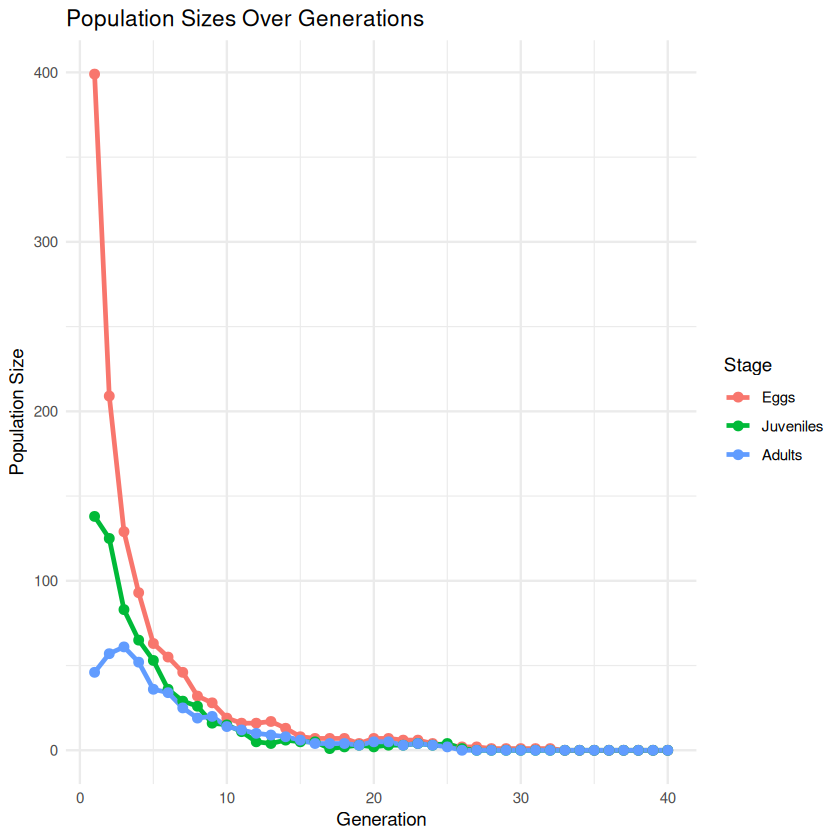

In [27]:
# create a dice roll function
roll_dice <- function(sides = 6, rolls = 1) {
  sample(1:sides, size = rolls, replace = TRUE)
}

NbGen = 40
NbEggs = 1000
NbJuvs = 0
NbAdlt = 0
Pop_vector <- c(NbEggs, NbJuvs, NbAdlt)
population_sizes <- data.frame(
  Generation = 1:NbGen,
  Eggs = integer(NbGen),
  Juveniles = integer(NbGen),
  Adults = integer(NbGen)
)
population_sizes[1, ] <- c(0, NbEggs, NbJuvs, NbAdlt)

for (generation in 1:NbGen) {

# decide the fate of eggs
vector_eggs_outcome = roll_dice( rolls = Pop_vector[1])
for (i in vector_eggs_outcome) {
  if (i %in% c(1, 2)) {
    NbEggs = NbEggs - 1
  } else if (i %in% c(3, 4)) {
    NbEggs = NbEggs
  } else {
    NbJuvs = NbJuvs + 1
    NbEggs = NbEggs - 1
  }
}
Pop_vector <- c(NbEggs, NbJuvs, NbAdlt)

# decide the fate of juveniles
vector_juvs_outcome = roll_dice( rolls = Pop_vector[2])
for (i in vector_juvs_outcome) {
if (i %in% c(1, 2)) {
    NbJuvs = NbJuvs - 1
} else if (i %in% c(3,4, 5)) {
    NbJuvs = NbJuvs
} else {
    NbAdlt = NbAdlt + 1
    NbJuvs = NbJuvs - 1
}
}
Pop_vector <- c(NbEggs, NbJuvs, NbAdlt)

# decide the fate of adults
vector_adults_outcome = roll_dice( rolls = Pop_vector[3])
for (i in vector_adults_outcome) {
if (i %in% c(1, 2)) {
    NbAdlt = NbAdlt - 1
} else  {
    NbEggs = NbEggs + 1
    NbAdlt = NbAdlt
}}
Pop_vector <- c(NbEggs, NbJuvs, NbAdlt)

if (NbEggs <= 0) {
    print(paste("Population went extinct at generation", generation))
    break}

population_sizes[generation, ] <- c(generation, NbEggs, NbJuvs, NbAdlt)
}

# graph population size over time
library(ggplot2)
library(reshape2)
population_sizes_melted <- melt(population_sizes, id.vars = "Generation", variable.name = "Stage", value.name = "Count")
ggplot(population_sizes_melted, aes(x = Generation, y = Count, color = Stage)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(title = "Population Sizes Over Generations",
       x = "Generation",
       y = "Population Size") +
  theme_minimal()

We can do the same using a multinomial probability law.

In [ ]:
NbGen = 40
NbEggs = 1000
NbJuvs = 0
NbAdlt = 0
Pop_vector <- c(NbEggs, NbJuvs, NbAdlt)
population_sizes <- data.frame(
  Generation = 1:NbGen,
  Eggs = integer(NbGen),
  Juveniles = integer(NbGen),
  Adults = integer(NbGen)
)
population_sizes[1, ] <- c(0, NbEggs, NbJuvs, NbAdlt)

for (generation in 1:NbGen) {

# decide the fate of eggs
vector_eggs_outcome = roll_dice( rolls = Pop_vector[1])
for (i in vector_eggs_outcome) {
  if (i %in% c(1, 2)) {
    NbEggs = NbEggs - 1
  } else if (i %in% c(3, 4)) {
    NbEggs = NbEggs
  } else {
    NbJuvs = NbJuvs + 1
    NbEggs = NbEggs - 1
  }
}
Pop_vector <- c(NbEggs, NbJuvs, NbAdlt)

# decide the fate of juveniles
vector_juvs_outcome = roll_dice( rolls = Pop_vector[2])
for (i in vector_juvs_outcome) {
if (i %in% c(1, 2)) {
    NbJuvs = NbJuvs - 1
} else if (i %in% c(3,4, 5)) {
    NbJuvs = NbJuvs
} else {
    NbAdlt = NbAdlt + 1
    NbJuvs = NbJuvs - 1
}
}
Pop_vector <- c(NbEggs, NbJuvs, NbAdlt)

# decide the fate of adults
vector_adults_outcome = roll_dice( rolls = Pop_vector[3])
for (i in vector_adults_outcome) {
if (i %in% c(1, 2)) {
    NbAdlt = NbAdlt - 1
} else  {
    NbEggs = NbEggs + 1
    NbAdlt = NbAdlt
}}
Pop_vector <- c(NbEggs, NbJuvs, NbAdlt)

if (NbEggs <= 0) {
    print(paste("Population went extinct at generation", generation))
    break}

population_sizes[generation, ] <- c(generation, NbEggs, NbJuvs, NbAdlt)
}

# graph population size over time
library(ggplot2)
library(reshape2)
population_sizes_melted <- melt(population_sizes, id.vars = "Generation", variable.name = "Stage", value.name = "Count")
ggplot(population_sizes_melted, aes(x = Generation, y = Count, color = Stage)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(title = "Population Sizes Over Generations",
       x = "Generation",
       y = "Population Size") +
  theme_minimal()